### Data exploration 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
#import data 
data=pd.read_csv('/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data.csv',sep=',')
data_donors=pd.read_csv('/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data_donatori.csv',sep=',')

In [3]:
#data cleaning 

#remove rows with TMTC
data=data[data['Conta']!='TMTC']
data.head()
data_donors=data_donors[data_donors['Conta']!='TMTC']
data_donors.head()

#Rename columns
data.rename(columns={'Idx Replica Condizione': 'Idx Replica Experiment','Controllo':'Control','Idx Replica Diluizione':'Idx Replica Diluition','Conta':'Count'}, inplace=True)
data_donors.rename(columns={'Idx Replica Diluizione':'Idx Replica Experiment','Controllo':'Control','Conta':'Count'}, inplace=True)

#dimensions and colunms
print("data_trasconjugant shape:", data.shape)
print("data_trasconjugant columns:", data.columns.tolist())
print("data_donors shape:", data_donors.shape)
print("data_donors columns:", data_donors.columns.tolist())

#add column with real counts
data['Real Count']=data['Count'].astype(int)*10^(-data['Diluition'])
data_donors['Real Count']=data_donors['Count'].astype(int)*10^(-data_donors['Diluition'])




data_trasconjugant shape: (378, 9)
data_trasconjugant columns: ['Idx Experiment', 'Idx Replica Diluition', 'Idx Replica Experiment', 'Control', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Count']
data_donors shape: (72, 7)
data_donors columns: ['Idx Experiment', 'Idx Replica Experiment', 'Diluition', 'IBU', 'DMSO', 'Temp', 'Count']


In [15]:
data.head()

,Idx Experiment,Idx Replica Diluition,Idx Replica Experiment,Control,Diluition,IBU,DMSO,Temp,Count,Real Count
3,1,1,A,No,-2,6.25,0,28,36,362
4,1,2,A,No,-2,6.25,0,28,33,328
5,1,3,A,No,-2,6.25,0,28,30,302
6,1,1,A,No,-3,6.25,0,28,4,43
7,1,2,A,No,-3,6.25,0,28,6,63


In [16]:
data_donors.head()

,Idx Experiment,Idx Replica Experiment,Diluition,IBU,DMSO,Temp,Count,Real Count
0,1,1,-6,6.25,0,28,51,504
1,1,2,-6,6.25,0,28,48,486
2,1,3,-6,6.25,0,28,50,498
3,1,1,-7,6.25,0,28,7,65
4,1,2,-7,6.25,0,28,3,25


##### Donors Counts 

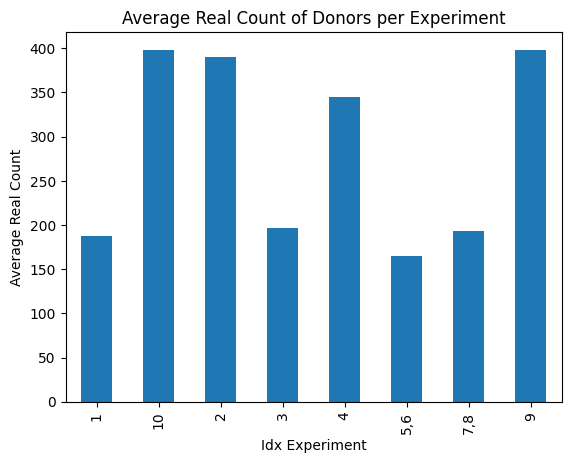

In [4]:
data_donors.groupby('Idx Experiment')['Real Count'].mean().plot(kind='bar')
plt.xlabel('Idx Experiment')
plt.ylabel('Average Real Count')
plt.title('Average Real Count of Donors per Experiment')
plt.show()


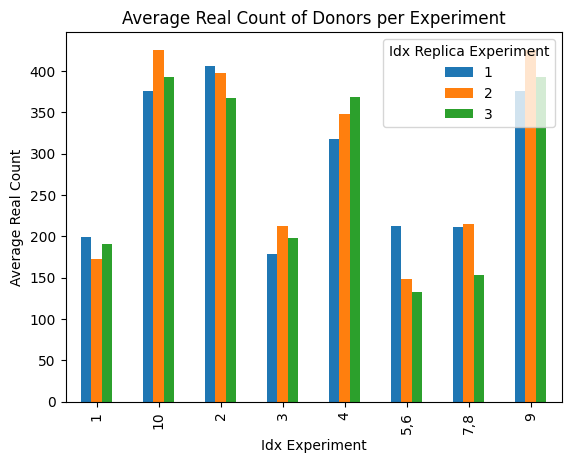

In [5]:
data_donors.groupby(['Idx Experiment','Idx Replica Experiment'])['Real Count'].mean().unstack('Idx Replica Experiment').plot(kind='bar')
plt.xlabel('Idx Experiment')
plt.ylabel('Average Real Count')
plt.title('Average Real Count of Donors per Experiment')
plt.show()
#we expect the same number of donors for each experiment replication

In [6]:
#overall mean of donors
#to have an idea order of magnitude of donors
overall_mean_donors=data_donors['Real Count'].mean()
print("Overall mean of donors:", overall_mean_donors)
#overall mean of log-donors
log_overall_mean_donors=np.log(data_donors['Real Count']).mean()
print("Log Overall mean of donors:", log_overall_mean_donors)
#overall std of donors
overall_std_donors=data_donors['Real Count'].std()
print("Overall std of donors:", overall_std_donors)
#overal std of log-donors
log_overall_std_donors=np.log(data_donors['Real Count']).std()
print("Log Overall std of donors:", log_overall_std_donors)

Overall mean of donors: 284.25
Log Overall mean of donors: 4.498557221828258
Overall std of donors: 357.0228915215697
Log Overall std of donors: 1.7874245019750559


##### Trasconjugant counts 

<Axes: xlabel='Idx Experiment,Idx Replica Experiment'>

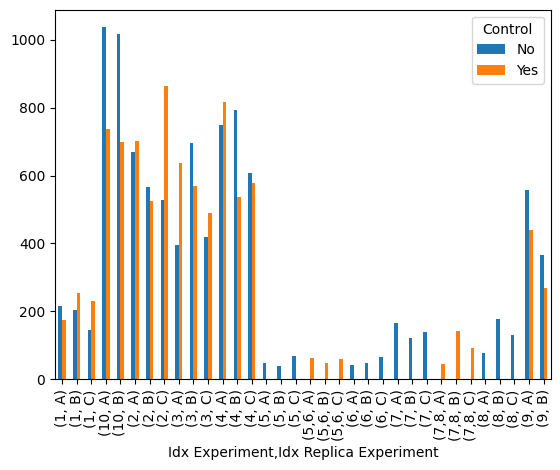

In [7]:
data.groupby(['Idx Experiment','Idx Replica Experiment','Control'])['Real Count'].mean().unstack('Control').plot(kind='bar')

<Axes: xlabel='Idx Experiment,Idx Replica Experiment,Control'>

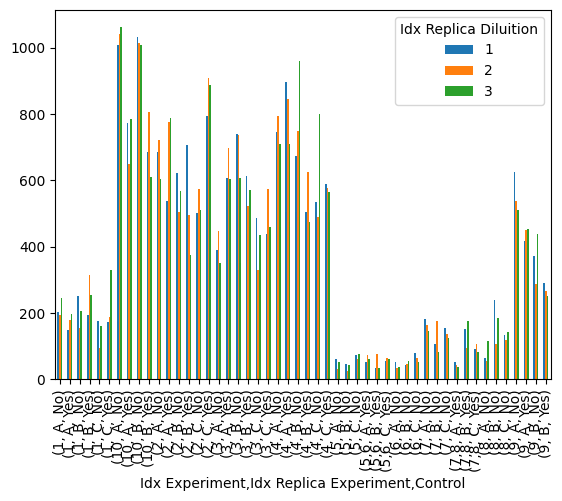

In [14]:
data.groupby(['Idx Experiment','Idx Replica Experiment','Idx Replica Diluition','Control'])['Real Count'].mean().unstack('Idx Replica Diluition').plot(kind='bar')

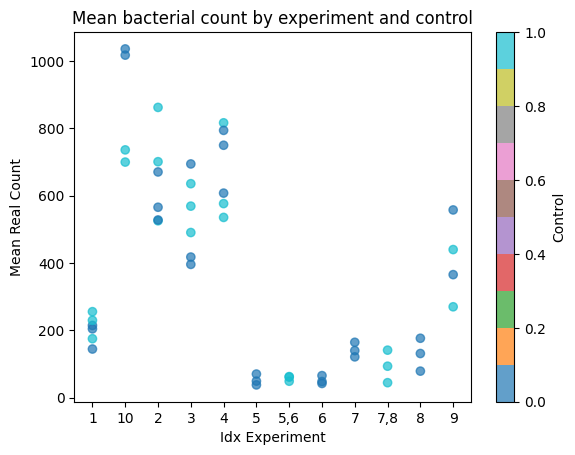

In [18]:
df_mean=(data.groupby(['Idx Experiment','Idx Replica Experiment','Control'],as_index=False)['Real Count'].mean())


#scatter plot
plt.scatter(
    x=df_mean['Idx Experiment'],
    y=df_mean['Real Count'],
    c=df_mean['Control'].astype('category').cat.codes, 
    cmap='tab10',
    alpha=0.7
)

plt.xlabel("Idx Experiment")
plt.ylabel("Mean Real Count")
plt.title("Mean bacterial count by experiment and control")
plt.colorbar(label="Control")
plt.show()

### DOE

<Axes: xlabel='IBU,DMSO'>

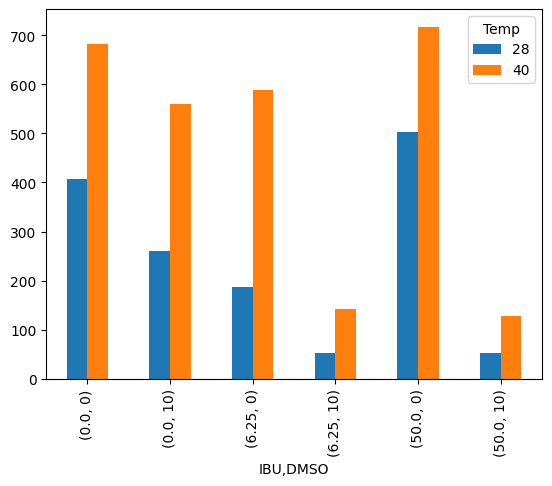

In [ ]:
#see effect of Temp
data.groupby(['Temp','IBU','DMSO'])['Real Count'].mean().unstack('Temp').plot(kind='bar')


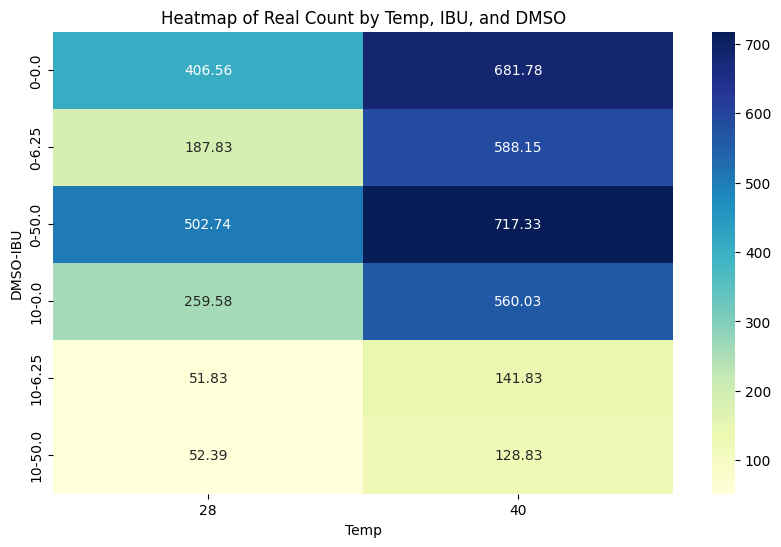

In [26]:
#heatmap 
pivot_table=data.pivot_table(values='Real Count', index=['DMSO','IBU'], columns='Temp', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Real Count by Temp, IBU, and DMSO")
plt.show()  

<Axes: xlabel='Temp,DMSO'>

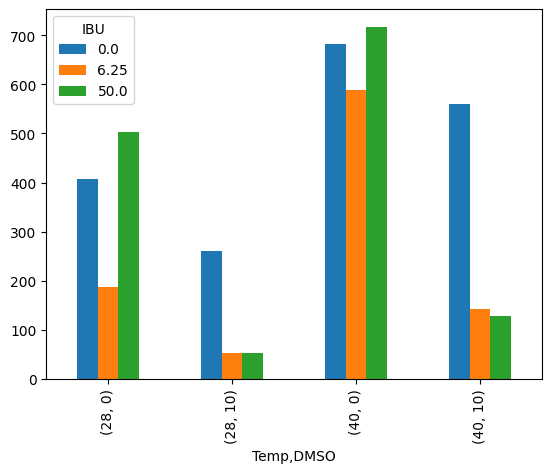

In [ ]:
#see effect of IBU
data.groupby(['Temp','IBU','DMSO'])['Real Count'].mean().unstack('IBU').plot(kind='bar')

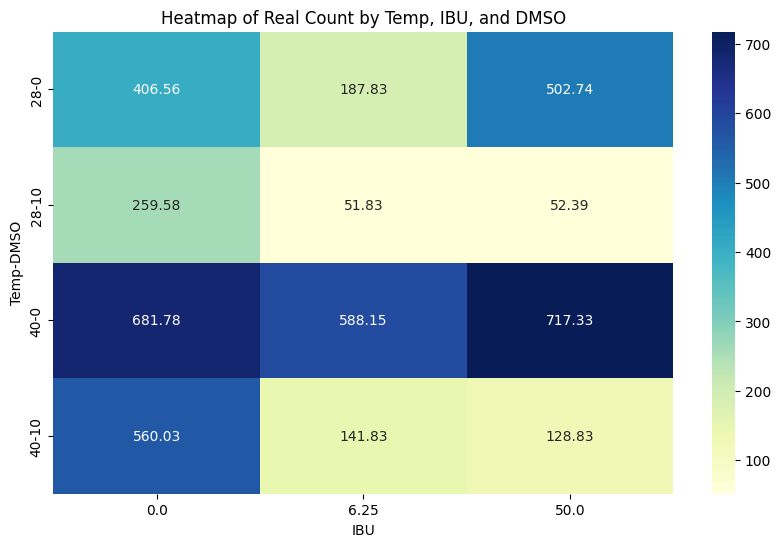

In [28]:
 #heatmap 
pivot_table=data.pivot_table(values='Real Count', index=['Temp','DMSO'], columns='IBU', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Real Count by Temp, IBU, and DMSO")
plt.show()          

<Axes: xlabel='Temp,IBU'>

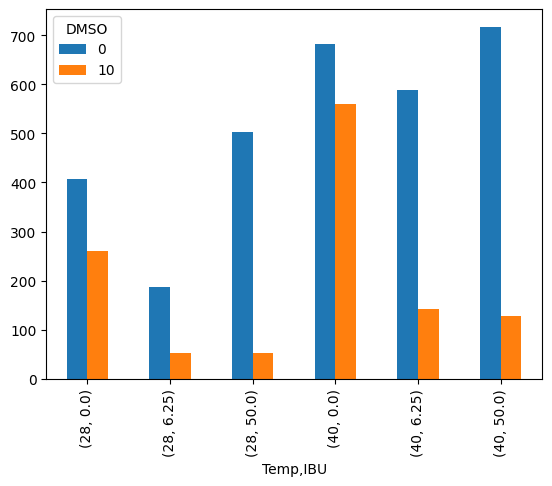

In [22]:
#see effect of DMSO
data.groupby(['Temp','IBU','DMSO'])['Real Count'].mean().unstack('DMSO').plot(kind='bar')

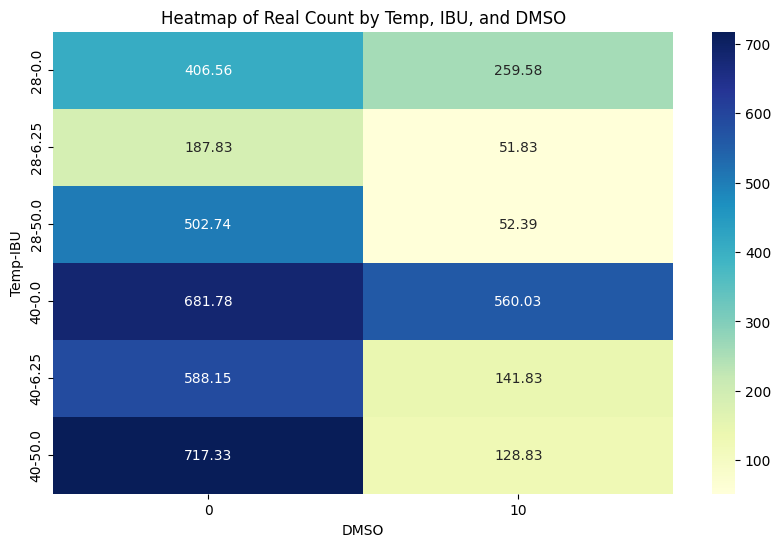

In [30]:
#heatmap 
pivot_table=data.pivot_table(values='Real Count', index=['Temp','IBU'], columns='DMSO', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Real Count by Temp, IBU, and DMSO")
plt.show() 

### Frequentist approach (maximumlikelihood)

In [36]:
#Idea: estimate the effect of Temp, DMSO and IBU assuming a poisson distribution with loglink function (generalized linear model)

dfD = pd.DataFrame({
    "D": data_donors['Real Count'],
    "exp": data_donors['Idx Experiment']
})

alpha_hat = (
    dfD.groupby("exp")["D"].mean()
)

alpha_hat = alpha_hat.to_dict()


In [43]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

X = data[["Temp", "IBU", "DMSO"]].values
Y = pd.to_numeric(data["Count"], errors="coerce")


dfY = pd.DataFrame(X, columns=[f"X{k}" for k in range(X.shape[1])])
dfY["Y"] = Y
dfY["rho_trasc"] = 10.0**(data['Diluition'])  
dfY["exp"] = data['Idx Experiment']
dfY["rep"] = data['Idx Replica Experiment']

# effetto fisso per (experiment × replica)
dfY["exp_rep"] = dfY["exp"].astype(str) + "_" + dfY["rep"].astype(str)

# alpha_hat per ogni osservazione
dfY["alpha_hat"] = dfY["exp"].map(alpha_hat)

# OFFSET = log(rho_trasc) + log(alpha_hat)
dfY["offset"] = np.log(dfY["rho_trasc"]) + np.log(dfY["alpha_hat"])


In [44]:
formula = "Y ~ " + " + ".join([f"X{k}" for k in range(X.shape[1])]) + " + C(exp_rep)"

fit_mle = smf.glm(
    formula=formula,
    data=dfY,
    family=sm.families.Poisson(),
    offset=dfY["offset"]
).fit()

print(fit_mle.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                      Y   No. Observations:                  276
Model:                            GLM   Df Residuals:                      254
Model Family:                 Poisson   Df Model:                           21
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1230.6
Date:                Sat, 07 Feb 2026   Deviance:                       1412.7
Time:                        13:15:17   Pearson chi2:                 1.24e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9999
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.57

In [45]:
beta_mle = fit_mle.params[[f"X{k}" for k in range(X.shape[1])]]
ci_mle = fit_mle.conf_int().loc[[f"X{k}" for k in range(X.shape[1])]]

print("MLE beta estimates:")
print(beta_mle)

print("\n95% Wald CI:")
print(ci_mle)


MLE beta estimates:
X0    0.001093
X1   -0.004823
X2    0.019135
dtype: float64

95% Wald CI:
           0         1
X0 -0.002949  0.005135
X1 -0.005738 -0.003908
X2  0.011820  0.026450
